# 📊 Customer Retention & Churn Analysis

## Future Interns – Data Science & Analytics Internship (Task 2)

### Objective

Analyze customer churn behavior to identify retention patterns, understand factors influencing customer attrition, and provide actionable recommendations to improve customer retention.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/Telco.csv", encoding="latin1")

In [3]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 7043
Number of Columns: 21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
total_customers = len(df)
churned = (df["Churn"]=="Yes").sum()
active = (df["Churn"]=="No").sum()
churn_rate = churned/total_customers*100
print("Total Customers:", total_customers)
print("Active Customers:", active)
print("Churned Customers:", churned)
print(f"Churn Rate: {churn_rate:.2f}%")

Total Customers: 7043
Active Customers: 5174
Churned Customers: 1869
Churn Rate: 26.54%


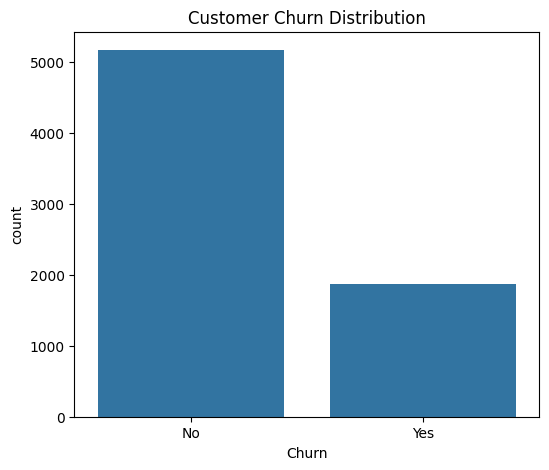

In [17]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.savefig("images/churn_distribution.png",dpi=300)
plt.show()

### Insights

- The majority of customers remain with the company, indicating a strong overall retention rate.
- However, a significant portion of customers have churned, highlighting opportunities to improve customer retention through targeted strategies.

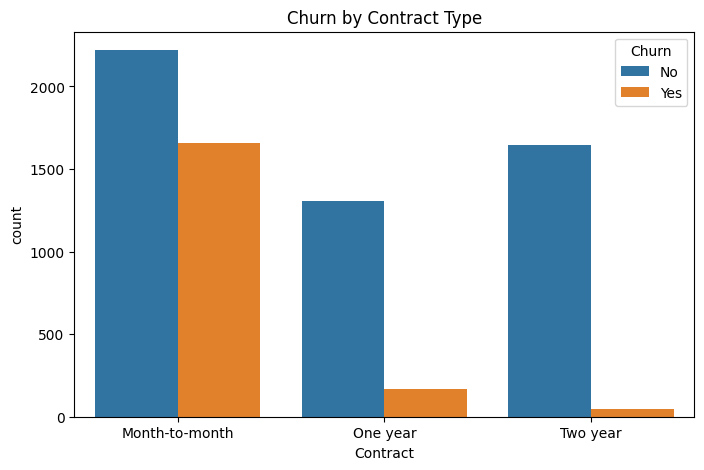

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.title("Churn by Contract Type")
plt.savefig("images/churn_by_contract.png",dpi=300)
plt.show()

### Insights

- Customers on month-to-month contracts have the highest churn rate.
- One-year contracts show considerably lower churn.
- Two-year contracts have the strongest retention, suggesting that longer commitments reduce customer attrition.

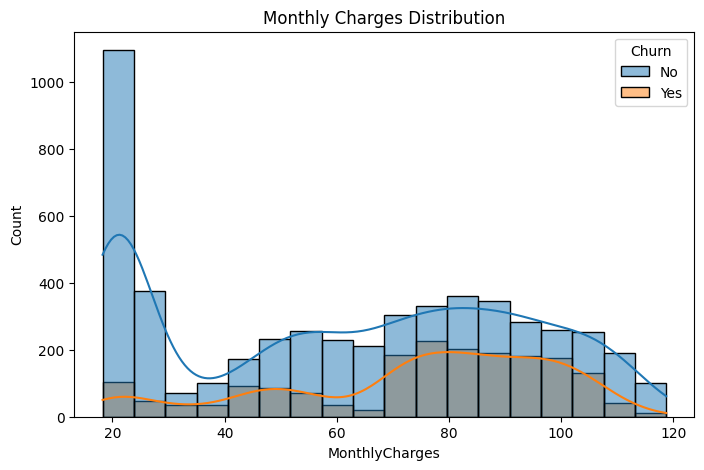

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)
plt.title("Monthly Charges Distribution")
plt.savefig("images/monthly_charges.png",dpi=300)
plt.show()

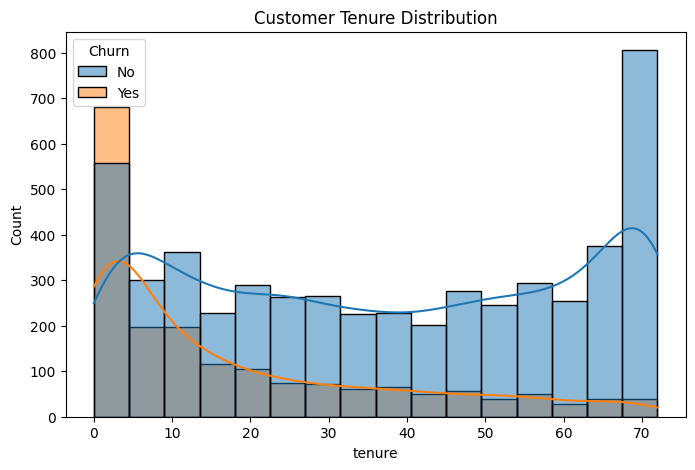

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)
plt.title("Customer Tenure Distribution")
plt.savefig("images/tenure_distribution.png",dpi=300)
plt.show()

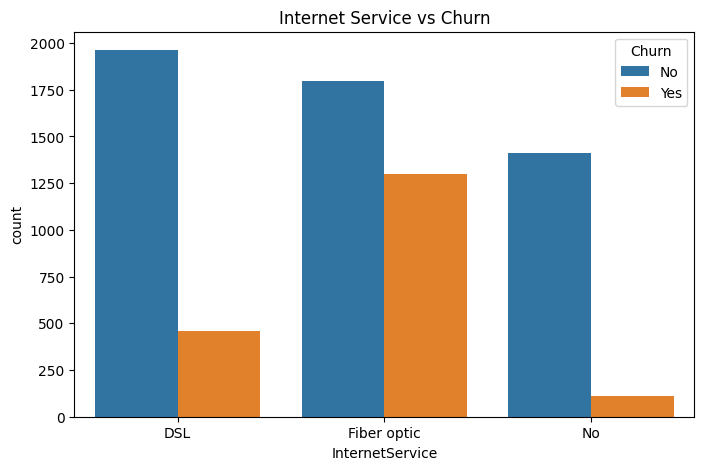

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)
plt.title("Internet Service vs Churn")
plt.savefig("images/internet_service.png",dpi=300)
plt.show()

### Insights

- Customers using Fiber Optic internet experience the highest churn rate.
- DSL users demonstrate better retention than Fiber Optic customers.
- Customers without internet service exhibit the lowest churn, indicating stable long-term relationships.

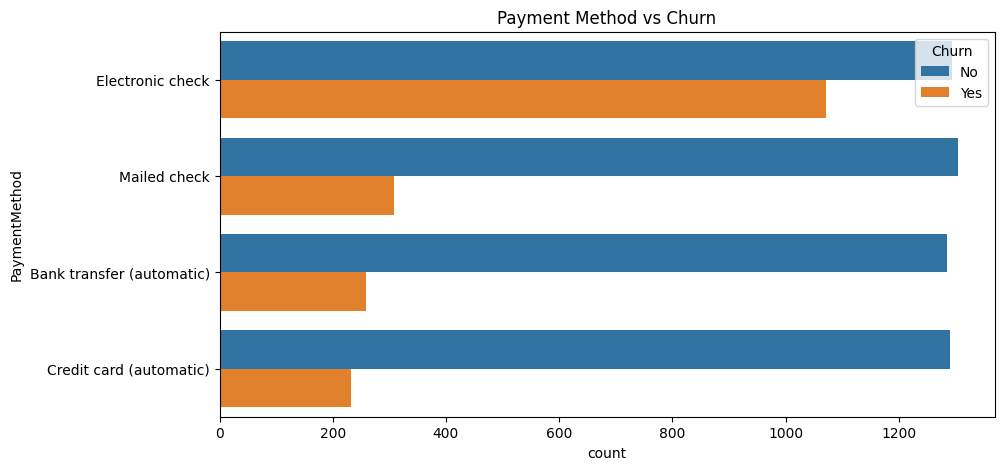

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="PaymentMethod",
    hue="Churn"
)
plt.title("Payment Method vs Churn")
plt.savefig("images/payment_method.png",dpi=300)
plt.show()

### Insights

- Customers paying through Electronic Check have the highest churn rate.
- Automatic payment methods (Bank Transfer and Credit Card) show significantly lower churn.
- Encouraging automatic payment options may improve customer retention.

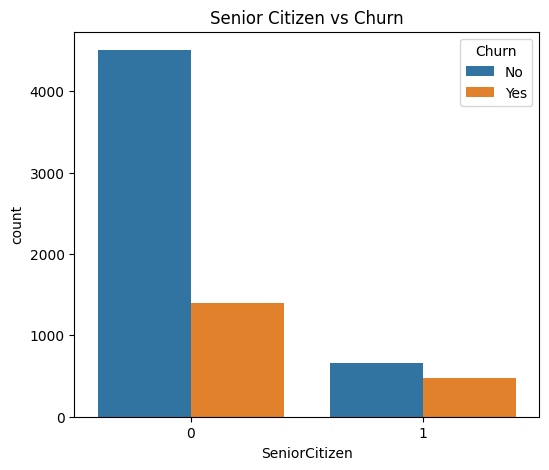

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)
plt.title("Senior Citizen vs Churn")
plt.savefig("images/senior_citizen.png",dpi=300)
plt.show()

### Insights

- Senior citizens are more likely to churn compared to non-senior customers.
- This customer segment may benefit from personalized support, simplified plans, or loyalty programs.

In [ ]:
df.columns.tolist()


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [21]:
total_customers = len(df)
churned_customers = (df["Churn"]=="Yes").sum()
active_customers = (df["Churn"]=="No").sum()
churn_rate = churned_customers/total_customers*100
print(f"Total Customers : {total_customers}")
print(f"Active Customers : {active_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate : {churn_rate:.2f}%")

Total Customers : 7043
Active Customers : 5174
Churned Customers: 1869
Overall Churn Rate : 26.54%


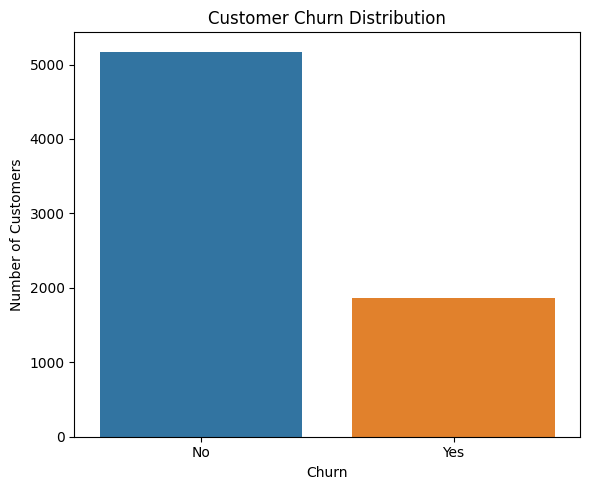

In [22]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/churn_distribution.png",dpi=300)
plt.show()

### Insights

- Customers with shorter tenure are significantly more likely to churn.
- Long-term customers demonstrate much stronger loyalty and retention.
- Improving the onboarding experience and early engagement may reduce churn among new customers.

In [23]:
contract_churn = pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


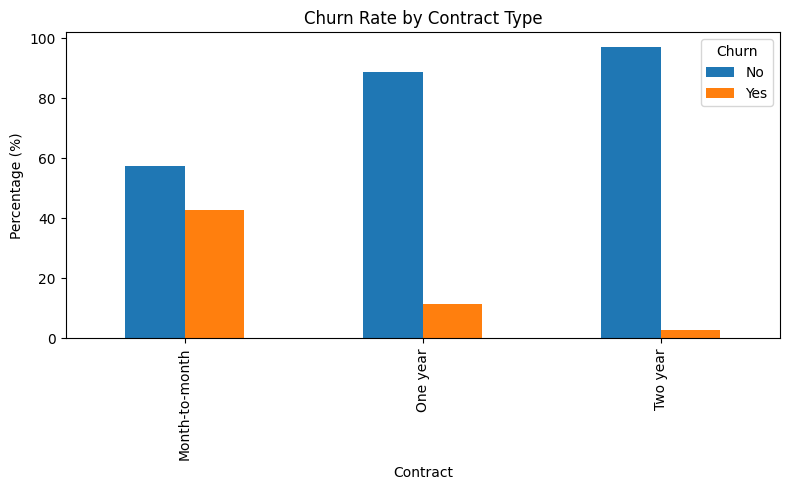

In [24]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.savefig("images/churn_by_contract.png",dpi=300)
plt.show()

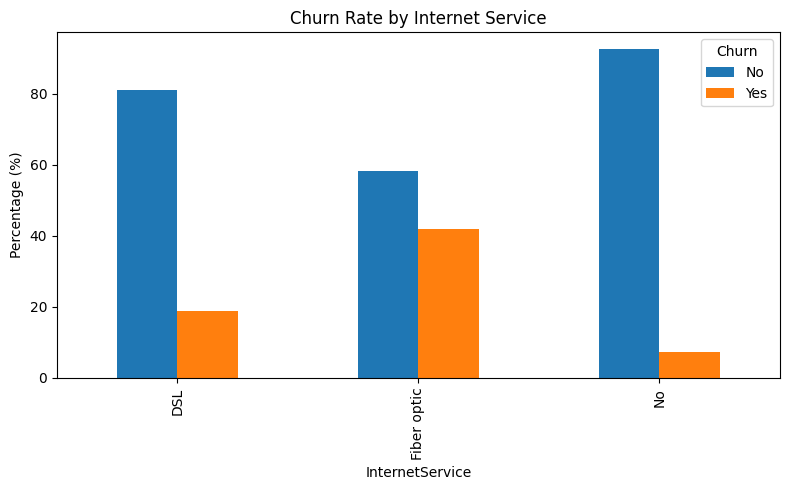

In [25]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Churn Rate by Internet Service")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.savefig("images/churn_by_internet.png",dpi=300)
plt.show()

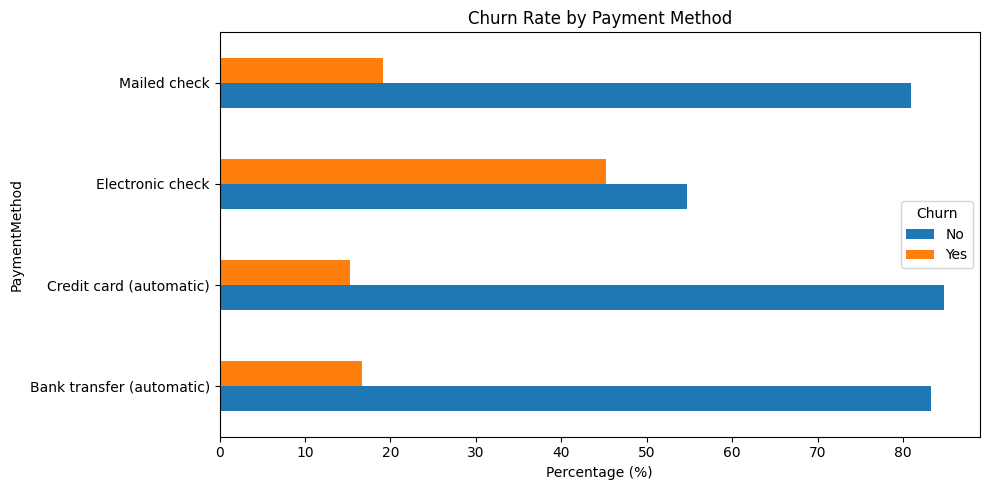

In [26]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100
payment_churn.plot(
    kind="barh",
    figsize=(10,5)
)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Percentage (%)")
plt.tight_layout()
plt.savefig("images/payment_method.png",dpi=300)
plt.show()

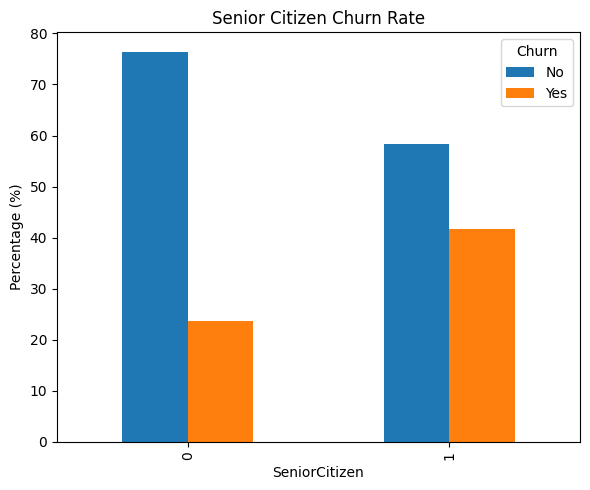

In [27]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)*100
senior_churn.plot(
    kind="bar",
    figsize=(6,5)
)
plt.title("Senior Citizen Churn Rate")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.savefig("images/senior_citizen.png",dpi=300)
plt.show()

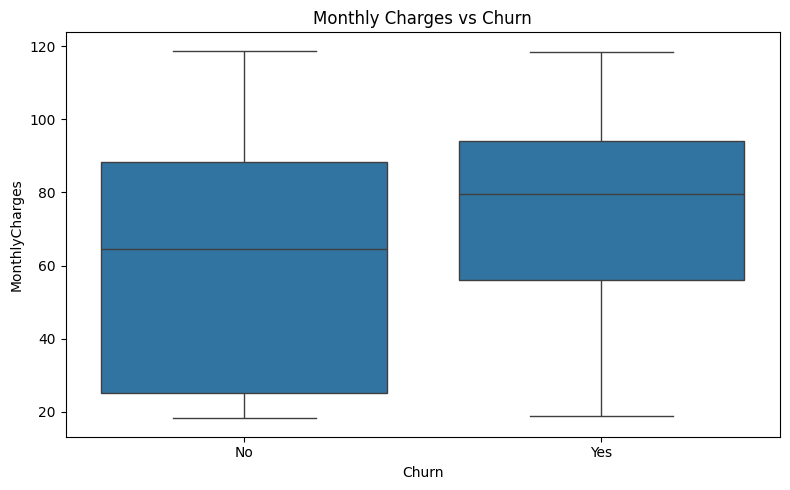

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig("images/monthly_charges_boxplot.png",dpi=300)
plt.show()

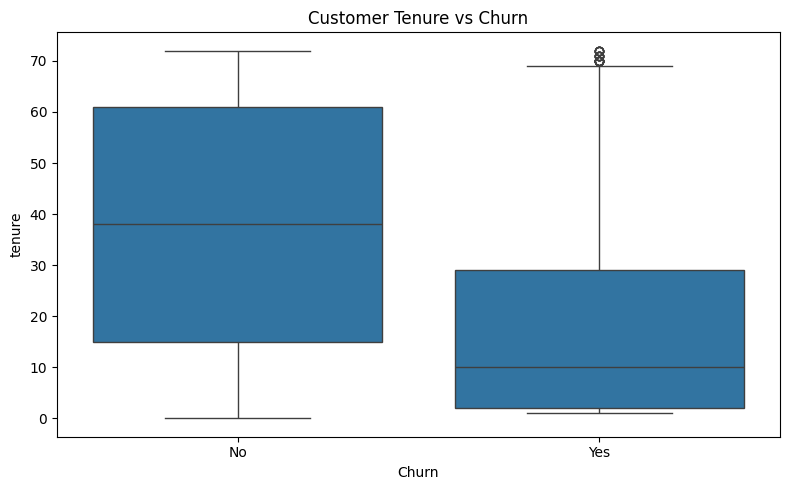

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.title("Customer Tenure vs Churn")
plt.tight_layout()
plt.savefig("images/tenure_boxplot.png",dpi=300)
plt.show()

### Insights

- Customers with shorter tenure are significantly more likely to churn.
- Long-term customers demonstrate much stronger loyalty and retention.
- Improving the onboarding experience and early engagement may reduce churn among new customers.

# Conclusion

This analysis identified key factors influencing customer churn, including contract type, internet service, payment method, monthly charges, and customer tenure.

The findings indicate that customers with month-to-month contracts, higher monthly charges, Fiber Optic internet service, and shorter tenure are more likely to churn.

Implementing targeted retention strategies based on these insights can improve customer loyalty, reduce churn, and support long-term business growth.